# clean_label v2, v3, v4 ??

? ???? ?? v2 5-class, v3 binary, v4 score stacking ??? ????? ?? feature? `audio(512) + text(512) + class one-hot(23)`? ?????. `top_class`? metadata ?? feature? ???? ????.

?? ??: `outputs/clean_label_v2_v3_v4`

In [1]:
from pathlib import Path
import os
import sys

HERE = Path.cwd()
if not (HERE / "clean_label_v2_v3_v4_experiments.py").exists():
    for parent in [HERE, *HERE.parents]:
        if (parent / "clean_label_v2_v3_v4_experiments.py").exists():
            HERE = parent
            break

os.chdir(HERE)
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import pandas as pd
from IPython.display import display, Image, Markdown
import clean_label_v2_v3_v4_experiments as clean

print("project root:", Path.cwd())
print("device:", clean.DEVICE)
print("output:", clean.OUTPUT_DIR)


project root: c:\Users\solok\Desktop\Dcase baseline
device: cuda
output: c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4


## 1. ?? ?? ??

?? epoch/patience? ??? `RUN_CONFIG`?? ??? ? ????. ?? ??? sanity check? ?? ??? `epochs`? ???, ?? ??? ????? ??? ???.

In [2]:
clean.RUN_CONFIG

{'seed': 42,
 'folds': 5,
 'epochs': 50,
 'patience': 7,
 'batch_size': 256,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'dropout': 0.3,
 'hidden': [512, 256],
 'expected_mse_weight': 0.25,
 'history_aggregation': 'pad',
 'train_final_bsd35k': True}

## 2. ??? ??? clean input ??

?? ?? BSD10k metadata? CLAP audio/text embedding? ????, clean feature ??? 1047?? ?????.

In [3]:
parts, class_categories = clean.load_bsd10k_parts()
y_1based = parts["df"]["confidence"].to_numpy()
y_binary = (y_1based >= 4).astype(int)

print("samples:", len(parts["df"]))
print("feature shape:", parts["x"].shape)
print("class count:", len(class_categories))
display(parts["df"][["sound_id", "class", "confidence"]].head())
display(pd.Series(y_1based).value_counts().sort_index().rename("confidence_count"))
display(pd.Series(y_binary).value_counts().sort_index().rename(index={0:"low(1-3)", 1:"high(4-5)"}).rename("binary_count"))

samples: 10956
feature shape: (10956, 1047)
class count: 23


,sound_id,class,confidence
0,185755,fx-o,4
1,358405,is-w,5
2,358760,is-w,4
3,432206,fx-o,4
4,80630,sp-s,5


1     106
2     749
3    3280
4    6045
5     776
Name: confidence_count, dtype: int64

low(1-3)     4135
high(4-5)    6821
Name: binary_count, dtype: int64

## 3. ?? ????? ??

?? ??: clean v2 5-class OOF -> clean v3 binary OOF -> clean v4 score stacking -> ????? BSD35k scoring.

?? ??? ?? `outputs/clean_label_v2_v3_v4` ??? ?????.

In [4]:
# ???? ?? ?????? ?? ?? ?? ? ????.
# clean.RUN_CONFIG["epochs"] = 5
# clean.RUN_CONFIG["patience"] = 2
# clean.RUN_CONFIG["train_final_bsd35k"] = False

result = clean.main()

clean_label feature shape: (10956, 1047)
device: cuda
clean_v2_ce fold=0 mae=0.5100 acc=0.5807
clean_v2_ce fold=1 mae=0.5200 acc=0.5842
clean_v2_ce fold=2 mae=0.5256 acc=0.5564
clean_v2_ce fold=3 mae=0.5059 acc=0.5888
clean_v2_ce fold=4 mae=0.5229 acc=0.5650
clean_v2_ordinal_smoothing fold=0 mae=0.5086 acc=0.5734
clean_v2_ordinal_smoothing fold=1 mae=0.5248 acc=0.5883
clean_v2_ordinal_smoothing fold=2 mae=0.5188 acc=0.5555
clean_v2_ordinal_smoothing fold=3 mae=0.5131 acc=0.5901
clean_v2_ordinal_smoothing fold=4 mae=0.5253 acc=0.5628
clean_v2_emd fold=0 mae=0.5019 acc=0.5844
clean_v2_emd fold=1 mae=0.5110 acc=0.5856
clean_v2_emd fold=2 mae=0.5215 acc=0.5614
clean_v2_emd fold=3 mae=0.5096 acc=0.5933
clean_v2_emd fold=4 mae=0.5151 acc=0.5609
clean_v2_expected_mse_aux fold=0 mae=0.5101 acc=0.5734
clean_v2_expected_mse_aux fold=1 mae=0.5185 acc=0.5851
clean_v2_expected_mse_aux fold=2 mae=0.5250 acc=0.5591
clean_v2_expected_mse_aux fold=3 mae=0.5044 acc=0.5865
clean_v2_expected_mse_aux fold=

## 4. v2/v3/v4 ?? ?

In [5]:
report_dir = clean.REPORT_DIR
pred_dir = clean.PRED_DIR
plot_dir = clean.PLOT_DIR

v2_summary = pd.read_csv(report_dir / "clean_v2_summary.csv")
v3_summary = pd.read_csv(report_dir / "clean_v3_binary_summary.csv")
v4_summary = pd.read_csv(report_dir / "clean_v4_score_stacking_summary.csv")

display(Markdown("### clean v2 5-class summary"))
display(v2_summary)
display(Markdown("### clean v3 binary summary"))
display(v3_summary)
display(Markdown("### clean v4 score stacking summary"))
display(v4_summary.head(12))

### clean v2 5-class summary

,experiment,feature_dim,mae_mean,mae_std,hard_mae_mean,hard_mae_std,accuracy_mean,accuracy_std,quadratic_weighted_kappa_mean,quadratic_weighted_kappa_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std,macro_f1_mean,macro_f1_std
0,clean_v2_emd,1047,0.511827,0.006469,0.472162,0.015811,0.577126,0.013394,0.324288,0.033372,0.415087,0.023732,0.289621,0.011130,0.303612,0.014269
1,clean_v2_expected_mse_aux,1047,0.516279,0.007853,0.483297,0.009818,0.573476,0.011107,0.307101,0.027194,0.416630,0.048567,0.287812,0.012855,0.302518,0.020930
2,clean_v2_ce,1047,0.516877,0.007613,0.483936,0.009836,0.575027,0.012279,0.304771,0.028507,0.413644,0.051196,0.295021,0.026134,0.310830,0.035232
3,clean_v2_ordinal_smoothing,1047,0.518116,0.006540,0.482749,0.009875,0.574023,0.013683,0.307873,0.040187,0.447801,0.096233,0.290665,0.014953,0.306246,0.021704


### clean v3 binary summary

,model,feature_dim,threshold,accuracy,precision,recall,f1,auc_pr,auc_roc
0,Binary MLP @ F1-optimal,1047,0.395,0.689942,0.694590,0.895910,0.782508,0.819018,0.738701
1,Binary MLP @ precision-optimal recall>=0.7,1047,0.605,0.680723,0.766480,0.700630,0.732077,0.819018,0.738701
2,Binary MLP @ threshold 0.5 reference,1047,0.500,0.693319,0.726951,0.812637,0.767410,0.819018,0.738701


### clean v4 score stacking summary

,method,score_column,selection,threshold,accuracy,precision,recall,f1,auc_pr,auc_roc
0,OOF logistic stacker,logistic_stacker_prob,F1-optimal,0.360,0.676707,0.672888,0.935493,0.782753,0.835443,0.753508
1,Rank average: binary + expected score,rank_average_binary_score,F1-optimal,0.150,0.675977,0.672067,0.936520,0.782555,0.837829,0.754128
2,Binary MLP probability,binary_mlp_prob,F1-optimal,0.395,0.689942,0.694590,0.895910,0.782508,0.819018,0.738701
3,Rank average: binary + P45,rank_average_binary_p45,F1-optimal,0.170,0.678624,0.677496,0.923325,0.781535,0.834560,0.751776
4,5-class expected score,fiveclass_score,F1-optimal,3.150,0.671595,0.668903,0.935640,0.780100,0.832473,0.746443
5,5-class expected score scaled 0-1,fiveclass_score_01,F1-optimal,0.540,0.672052,0.670074,0.932268,0.779719,0.832473,0.746443
6,5-class P4+P5,fiveclass_p45,F1-optimal,0.355,0.678715,0.683003,0.903093,0.777778,0.825959,0.741276
7,5-class margin P45-P3,fiveclass_margin_p45_minus_p3,F1-optimal,-0.150,0.670683,0.677533,0.898842,0.772653,0.824773,0.736437
8,Rank average: binary + P45,rank_average_binary_p45,precision-optimal @ recall>=0.7,0.435,0.689211,0.775840,0.704296,0.738339,0.834560,0.751776
9,OOF logistic stacker,logistic_stacker_prob,precision-optimal @ recall>=0.7,0.610,0.690581,0.779990,0.700630,0.738184,0.835443,0.753508


## 5. ?? ?? vs clean input ?? ??

?? ????? clean input ????? ??? ?? feature???? ???. ?? ?? ??? ? ??? clean ??? ?? v2/v3/v4 ??? ?? ???? ??? ?????.


In [6]:
def _read(path):
    path = Path(path)
    return pd.read_csv(path) if path.exists() else None

comparison_blocks = {}

orig_v2 = _read("outputs/confidence_model_v2/reports/v2_experiment_summary.csv")
clean_v2 = _read(report_dir / "clean_v2_summary.csv")
if orig_v2 is not None and clean_v2 is not None:
    orig_v2_view = orig_v2[orig_v2["experiment"].isin([
        "stage2_baseline_ce",
        "stage2_baseline_ordinal_smoothing",
        "stage2_baseline_emd",
        "stage2_baseline_expected_mse_aux",
    ])].copy()
    orig_v2_view = orig_v2_view.rename(columns={
        "mae": "mae_mean",
        "accuracy": "accuracy_mean",
        "quadratic_weighted_kappa": "quadratic_weighted_kappa_mean",
        "macro_f1": "macro_f1_mean",
    })
    orig_v2_view["source"] = "original_v2"
    clean_v2_view = clean_v2.copy()
    clean_v2_view["source"] = "clean_input_v2"
    comparison_blocks["v2"] = pd.concat([
        orig_v2_view[["source", "experiment", "feature_dim", "mae_mean", "accuracy_mean", "quadratic_weighted_kappa_mean", "macro_f1_mean"]],
        clean_v2_view[["source", "experiment", "feature_dim", "mae_mean", "accuracy_mean", "quadratic_weighted_kappa_mean", "macro_f1_mean"]],
    ], ignore_index=True)

orig_v3 = _read("outputs/confidence_filter_v3/reports/stage1_binary_mlp_oof_metrics.csv")
clean_v3 = _read(report_dir / "clean_v3_binary_summary.csv")
if orig_v3 is not None and clean_v3 is not None:
    orig_v3_view = orig_v3.copy(); orig_v3_view["source"] = "original_v3"
    clean_v3_view = clean_v3.copy(); clean_v3_view["source"] = "clean_input_v3"
    comparison_blocks["v3"] = pd.concat([
        orig_v3_view[["source", "model", "threshold", "accuracy", "precision", "recall", "f1", "auc_pr", "auc_roc"]],
        clean_v3_view[["source", "model", "threshold", "accuracy", "precision", "recall", "f1", "auc_pr", "auc_roc"]],
    ], ignore_index=True)

orig_v4 = _read("outputs/confidence_filter_v4/reports/v4_all_method_summary.csv")
clean_v4 = _read(report_dir / "clean_v4_score_stacking_summary.csv")
if orig_v4 is not None and clean_v4 is not None:
    orig_v4_view = orig_v4.copy(); orig_v4_view["source"] = "original_v4"
    clean_v4_view = clean_v4.copy(); clean_v4_view["source"] = "clean_input_v4"
    comparison_blocks["v4"] = pd.concat([
        orig_v4_view[["source", "method", "selection", "threshold", "accuracy", "precision", "recall", "f1", "auc_pr", "auc_roc"]],
        clean_v4_view[["source", "method", "selection", "threshold", "accuracy", "precision", "recall", "f1", "auc_pr", "auc_roc"]],
    ], ignore_index=True)

for name, df_cmp in comparison_blocks.items():
    display(Markdown(f"### {name}"))
    display(df_cmp)


### v2

,source,experiment,feature_dim,mae_mean,accuracy_mean,quadratic_weighted_kappa_mean,macro_f1_mean
0,original_v2,stage2_baseline_emd,1056,0.508742,0.580869,0.337494,0.306156
1,original_v2,stage2_baseline_ordinal_smoothing,1056,0.514191,0.580047,0.343299,0.313934
2,original_v2,stage2_baseline_ce,1056,0.514462,0.576762,0.329924,0.307519
3,original_v2,stage2_baseline_expected_mse_aux,1056,0.514623,0.577857,0.325848,0.300854
4,clean_input_v2,clean_v2_emd,1047,0.511827,0.577126,0.324288,0.303612
5,clean_input_v2,clean_v2_expected_mse_aux,1047,0.516279,0.573476,0.307101,0.302518
6,clean_input_v2,clean_v2_ce,1047,0.516877,0.575027,0.304771,0.310830
7,clean_input_v2,clean_v2_ordinal_smoothing,1047,0.518116,0.574023,0.307873,0.306246


### v3

,source,model,threshold,accuracy,precision,recall,f1,auc_pr,auc_roc
0,original_v3,Binary MLP @ F1-optimal,0.400,0.687203,0.690417,0.902067,0.782178,0.825957,0.746148
1,original_v3,Binary MLP @ precision-optimal recall>=0.7,0.585,0.684739,0.772279,0.700044,0.734389,0.825957,0.746148
2,original_v3,Binary MLP @ threshold 0.5 reference,0.500,0.700438,0.734278,0.813077,0.771671,0.825957,0.746148
3,clean_input_v3,Binary MLP @ F1-optimal,0.395,0.689942,0.694590,0.895910,0.782508,0.819018,0.738701
4,clean_input_v3,Binary MLP @ precision-optimal recall>=0.7,0.605,0.680723,0.766480,0.700630,0.732077,0.819018,0.738701
5,clean_input_v3,Binary MLP @ threshold 0.5 reference,0.500,0.693319,0.726951,0.812637,0.767410,0.819018,0.738701


### v4

,source,method,selection,threshold,accuracy,precision,recall,f1,auc_pr,auc_roc
0,original_v4,Binary MLP probability,F1-optimal,0.400,0.687203,0.690417,0.902067,0.782178,0.825957,0.746148
1,original_v4,Binary MLP probability,precision-optimal @ recall>=0.7,0.585,0.684739,0.772279,0.700044,0.734389,0.825957,0.746148
2,original_v4,5-class P4+P5,F1-optimal,0.330,0.677163,0.674755,0.929482,0.781896,0.830483,0.748871
3,original_v4,5-class P4+P5,precision-optimal @ recall>=0.7,0.640,0.686747,0.773351,0.702829,0.736406,0.830483,0.748871
4,original_v4,5-class expected score,F1-optimal,3.140,0.671230,0.665467,0.948981,0.782330,0.837443,0.752323
5,original_v4,5-class expected score,precision-optimal @ recall>=0.7,3.610,0.688116,0.773194,0.706201,0.738181,0.837443,0.752323
6,original_v4,5-class expected score scaled 0-1,F1-optimal,0.535,0.671230,0.665467,0.948981,0.782330,0.837443,0.752323
7,original_v4,5-class expected score scaled 0-1,precision-optimal @ recall>=0.7,0.650,0.688938,0.770230,0.713092,0.740560,0.837443,0.752323
8,original_v4,5-class margin P45-P3,F1-optimal,-0.155,0.671961,0.674489,0.914382,0.776326,0.829517,0.744816
9,original_v4,5-class margin P45-P3,precision-optimal @ recall>=0.7,0.325,0.685195,0.771935,0.701657,0.735120,0.829517,0.744816


## 6. Train loss + Validation loss ???

? fold history? epoch ???? padding aggregation? ? ?? train loss? ?? validation loss? ? ??? ?????.

### clean_v2_ce

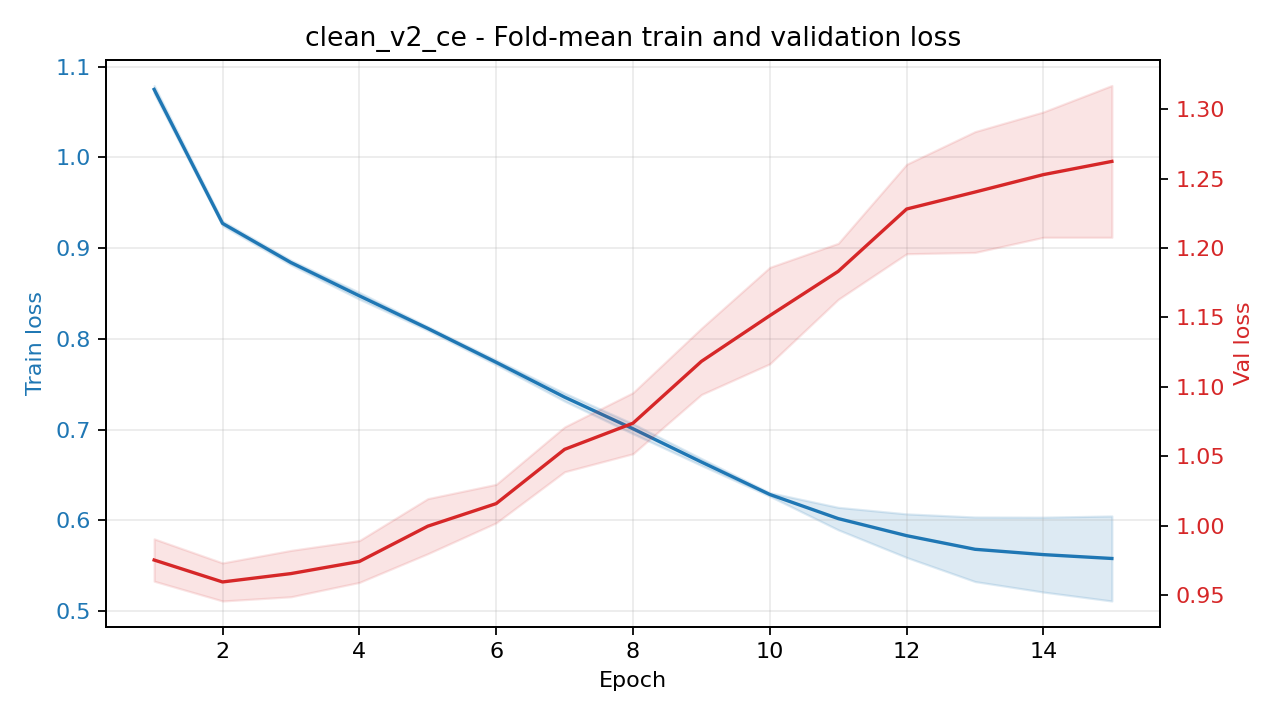

,epoch,train_loss_mean,train_loss_std,val_loss_mean,val_loss_std,val_mae_mean,val_mae_std
0,1,1.074863,0.004292,0.975364,0.015236,0.541037,0.007056
1,2,0.927178,0.002584,0.959572,0.013698,0.529096,0.005585
2,3,0.884017,0.002608,0.965597,0.016688,0.521156,0.004845
3,4,0.847351,0.003748,0.974308,0.015065,0.520495,0.004374
4,5,0.811433,0.002201,0.999721,0.019828,0.522859,0.009696


### clean_v2_ordinal_smoothing

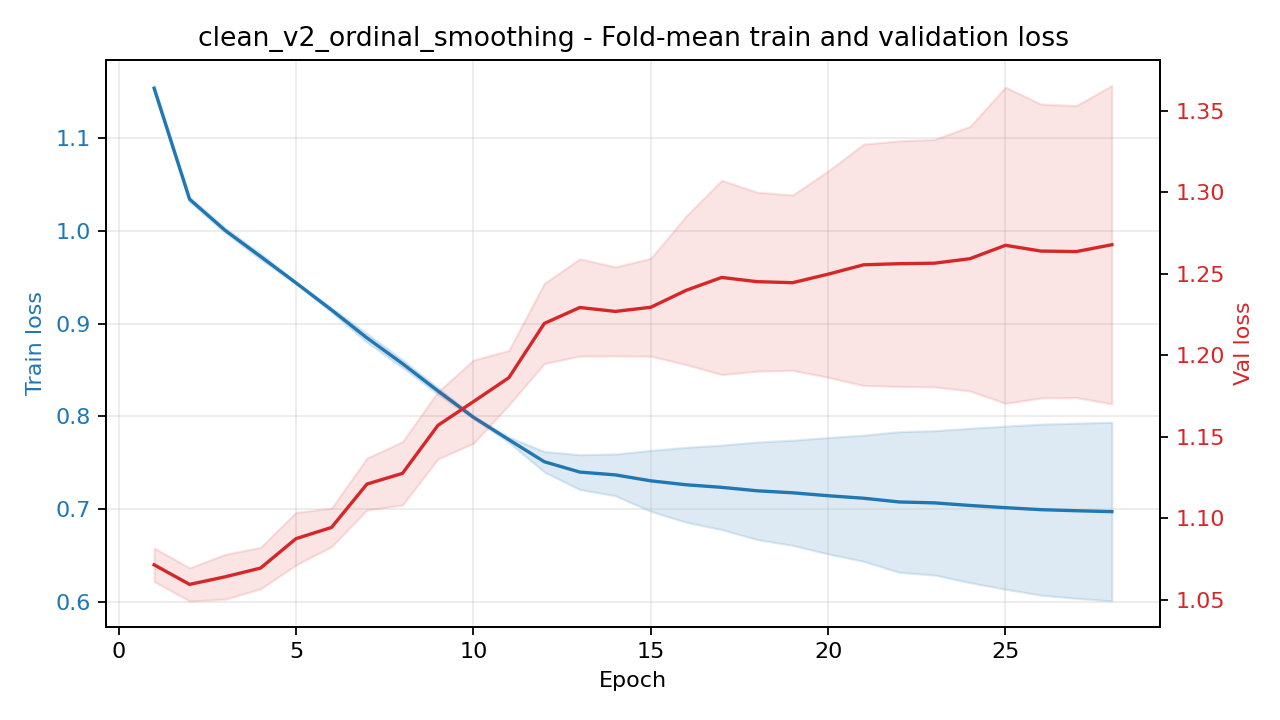

,epoch,train_loss_mean,train_loss_std,val_loss_mean,val_loss_std,val_mae_mean,val_mae_std
0,1,1.153693,0.002976,1.071320,0.010321,0.544882,0.003811
1,2,1.034064,0.002317,1.059313,0.010175,0.534193,0.007916
2,3,1.000621,0.002524,1.063959,0.013757,0.527352,0.004446
3,4,0.972451,0.003105,1.069317,0.012755,0.524230,0.004506
4,5,0.943962,0.000999,1.087381,0.016131,0.524139,0.008513


### clean_v2_emd

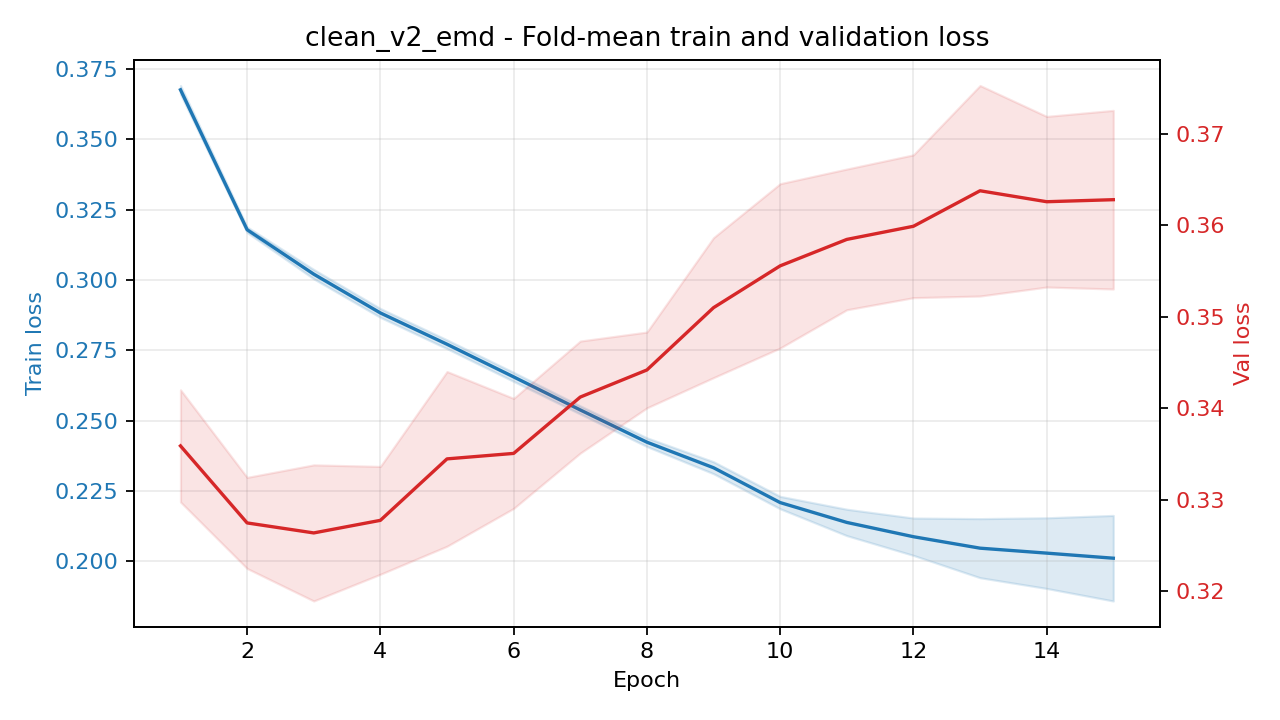

,epoch,train_loss_mean,train_loss_std,val_loss_mean,val_loss_std,val_mae_mean,val_mae_std
0,1,0.367680,0.001525,0.335871,0.006131,0.531090,0.007915
1,2,0.317903,0.000994,0.327448,0.004979,0.521693,0.003770
2,3,0.302099,0.001662,0.326355,0.007439,0.516680,0.004019
3,4,0.288297,0.001581,0.327731,0.005894,0.515052,0.006389
4,5,0.277162,0.001559,0.334450,0.009549,0.516862,0.011611


### clean_v2_expected_mse_aux

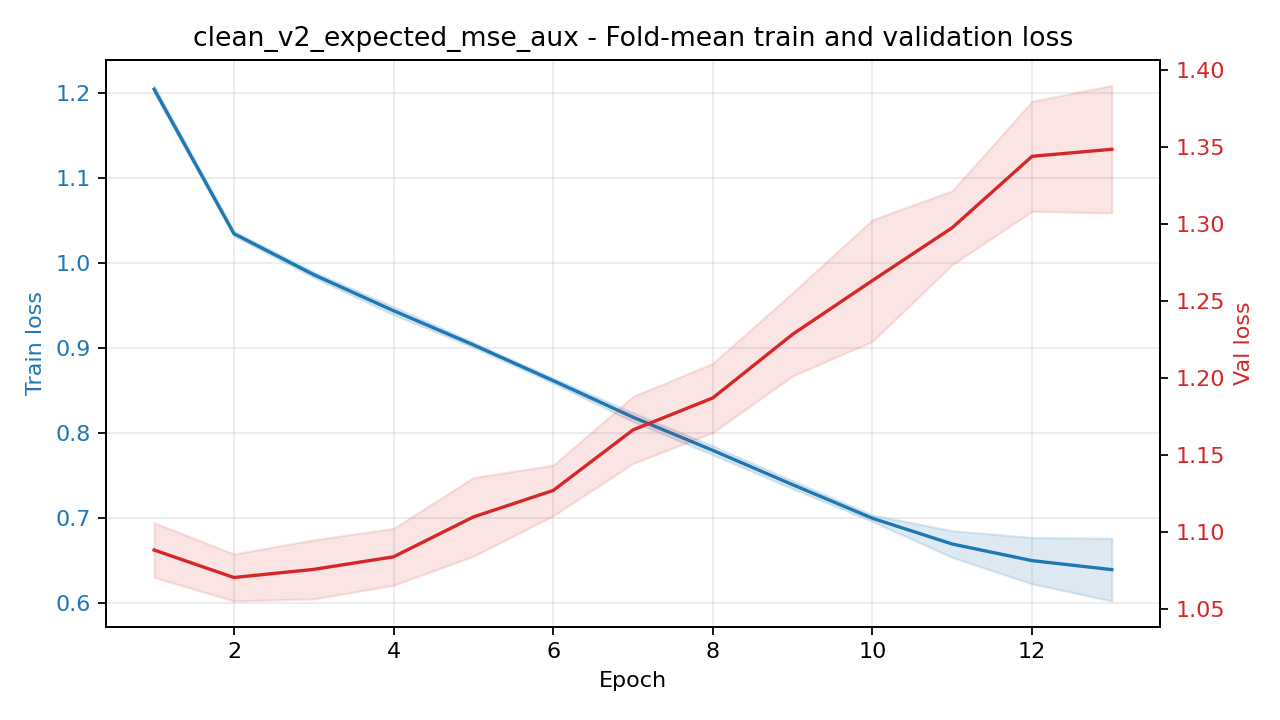

,epoch,train_loss_mean,train_loss_std,val_loss_mean,val_loss_std,val_mae_mean,val_mae_std
0,1,1.204168,0.004362,1.088359,0.017788,0.539668,0.007315
1,2,1.034272,0.002998,1.070491,0.015248,0.528185,0.004803
2,3,0.986041,0.003434,1.075787,0.019201,0.520729,0.004736
3,4,0.943640,0.004692,1.083951,0.018474,0.520233,0.004762
4,5,0.903486,0.003114,1.109863,0.025586,0.522095,0.010579


### clean_v3_binary

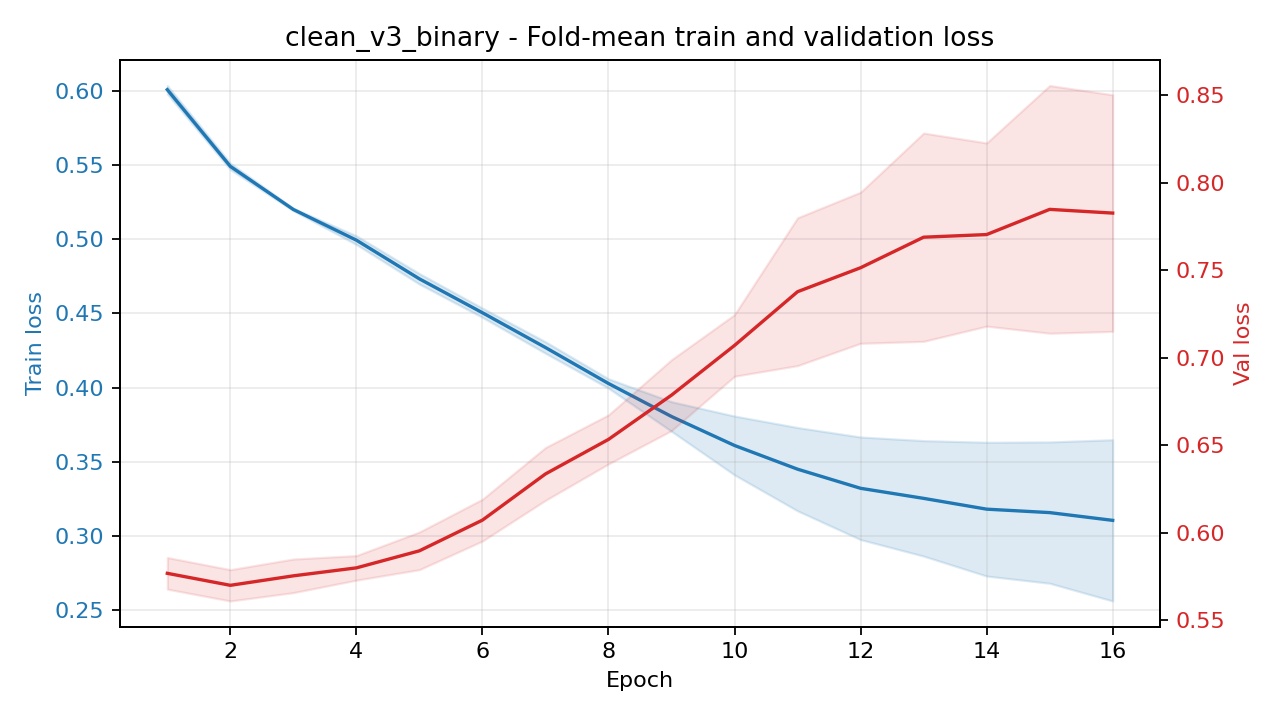

,epoch,train_loss_mean,train_loss_std,val_loss_mean,val_loss_std,val_f1_best_threshold_mean,val_f1_best_threshold_std,val_auc_pr_mean,val_auc_pr_std
0,1,0.601099,0.002808,0.576865,0.009038,0.780404,0.004262,0.826772,0.009993
1,2,0.549301,0.002134,0.570014,0.008948,0.782724,0.002424,0.832335,0.008487
2,3,0.520208,0.000802,0.575429,0.009595,0.783192,0.002986,0.832371,0.006379
3,4,0.499500,0.002943,0.579975,0.007018,0.782719,0.003242,0.831688,0.003676
4,5,0.473366,0.003538,0.589715,0.010749,0.783974,0.002419,0.830232,0.005932


In [7]:
plot_names = [
    "clean_v2_ce",
    "clean_v2_ordinal_smoothing",
    "clean_v2_emd",
    "clean_v2_expected_mse_aux",
    "clean_v3_binary",
]

for name in plot_names:
    img = plot_dir / f"{name}_train_loss_val_loss.png"
    csv = report_dir / f"{name}_mean_history.csv"
    display(Markdown(f"### {name}"))
    if img.exists():
        display(Image(filename=str(img)))
    else:
        print("missing plot:", img)
    if csv.exists():
        display(pd.read_csv(csv).head())

## 7. ??? Confusion Matrix

v2? 5-class OOF prediction ?? 5x5 row-normalized matrix??, v3/v4? `confidence >= 4` binary ?? 2x2 row-normalized matrix???.

### clean_v2_ce

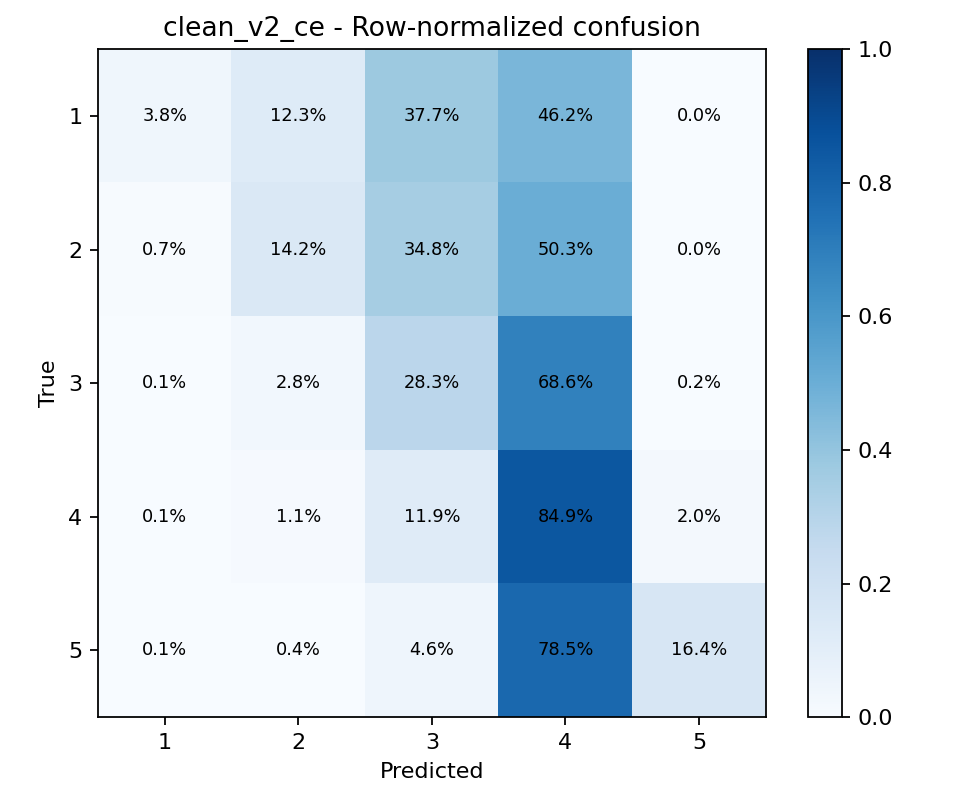

,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,0.037736,0.122642,0.377358,0.462264,0.000000
true_2,0.006676,0.141522,0.348465,0.503338,0.000000
true_3,0.000610,0.028049,0.282927,0.685976,0.002439
true_4,0.000662,0.011249,0.118941,0.849462,0.019686
true_5,0.001289,0.003866,0.046392,0.784794,0.163660


### clean_v2_ordinal_smoothing

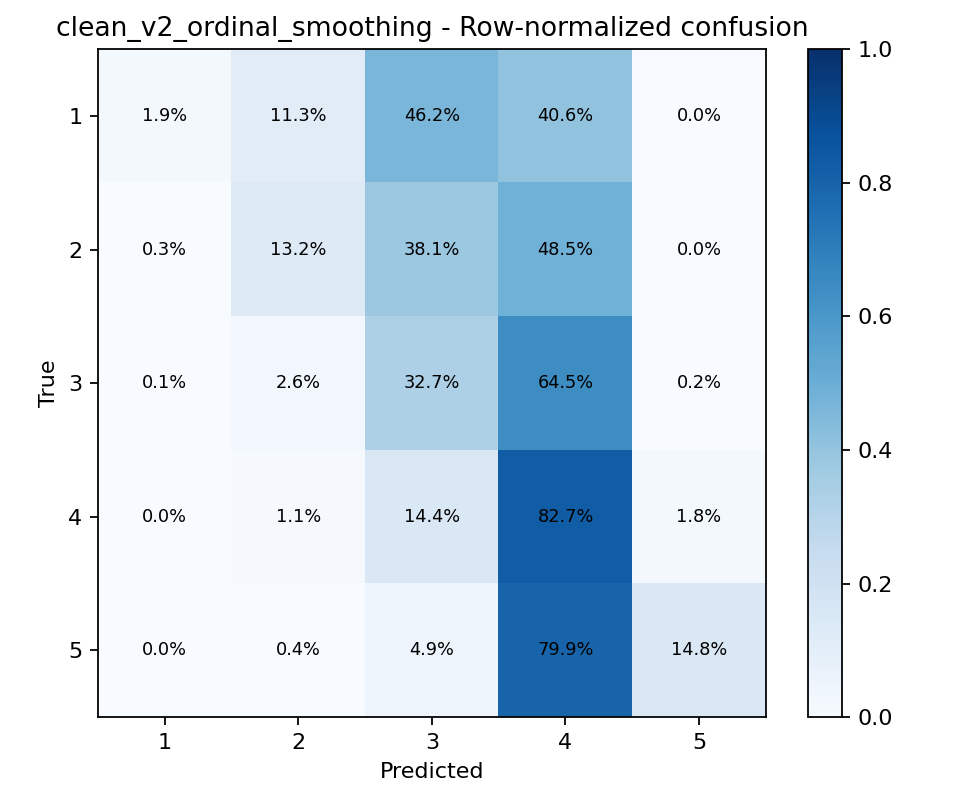

,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,0.018868,0.113208,0.462264,0.405660,0.000000
true_2,0.002670,0.132176,0.380507,0.484646,0.000000
true_3,0.000610,0.025610,0.327439,0.644512,0.001829
true_4,0.000331,0.011249,0.143590,0.826964,0.017866
true_5,0.000000,0.003866,0.048969,0.798969,0.148196


### clean_v2_emd

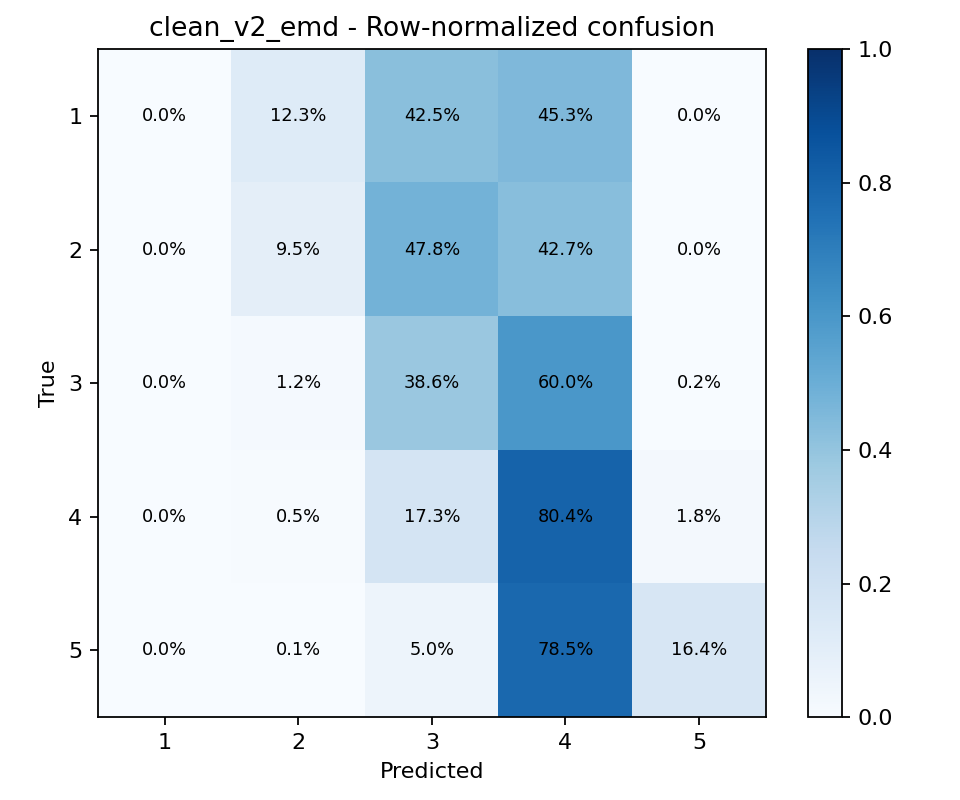

,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,0.0,0.122642,0.424528,0.452830,0.000000
true_2,0.0,0.094793,0.477971,0.427236,0.000000
true_3,0.0,0.012195,0.385671,0.600000,0.002134
true_4,0.0,0.005128,0.172705,0.803970,0.018197
true_5,0.0,0.001289,0.050258,0.784794,0.163660


### clean_v2_expected_mse_aux

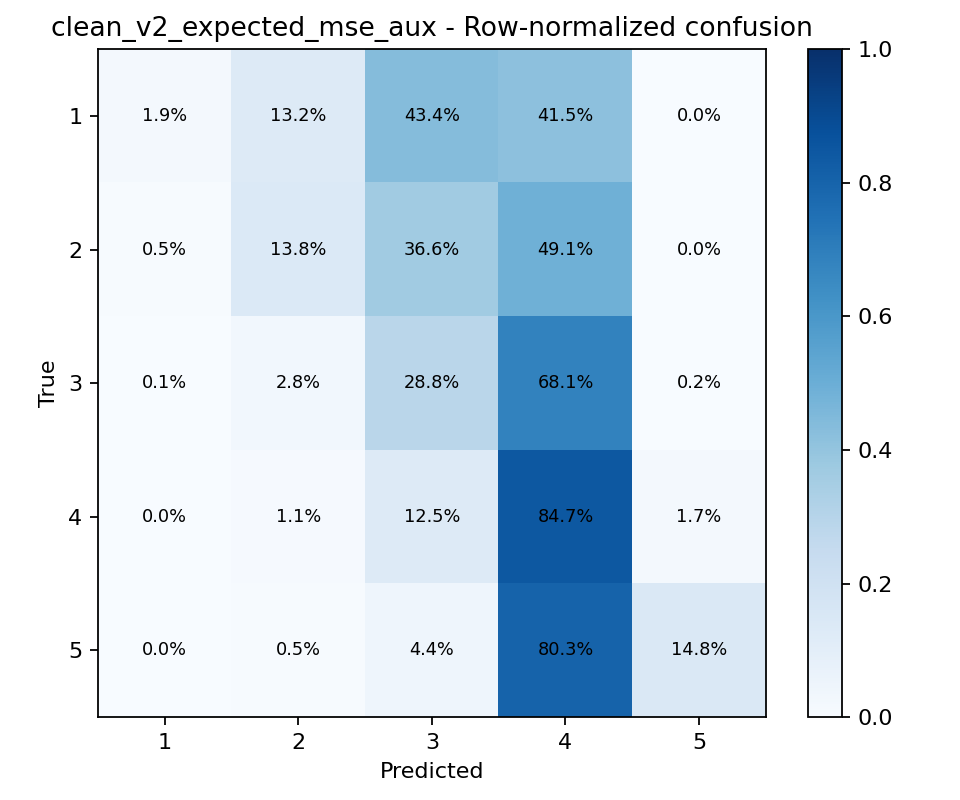

,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,0.018868,0.132075,0.433962,0.415094,0.000000
true_2,0.005340,0.137517,0.365821,0.491322,0.000000
true_3,0.000915,0.028049,0.288110,0.681098,0.001829
true_4,0.000331,0.010753,0.125062,0.846650,0.017204
true_5,0.000000,0.005155,0.043814,0.802835,0.148196


### clean_v3_binary_f1_optimal

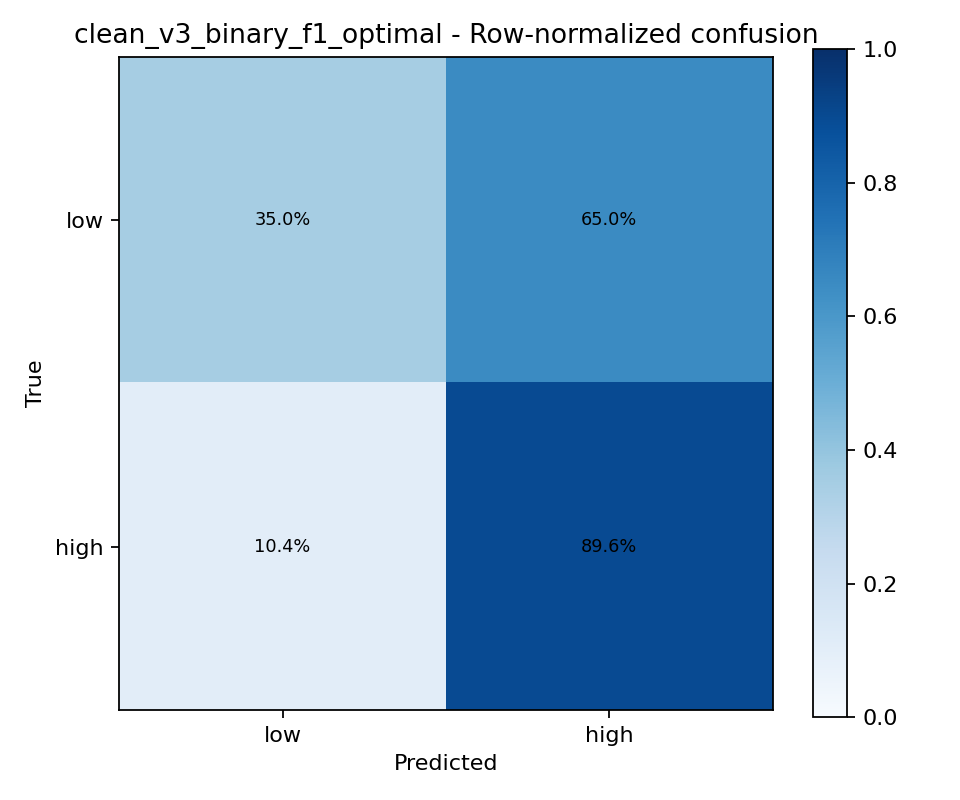

,pred_low,pred_high
true_low,0.350181,0.649819
true_high,0.104090,0.895910


### clean_v4_best_binary

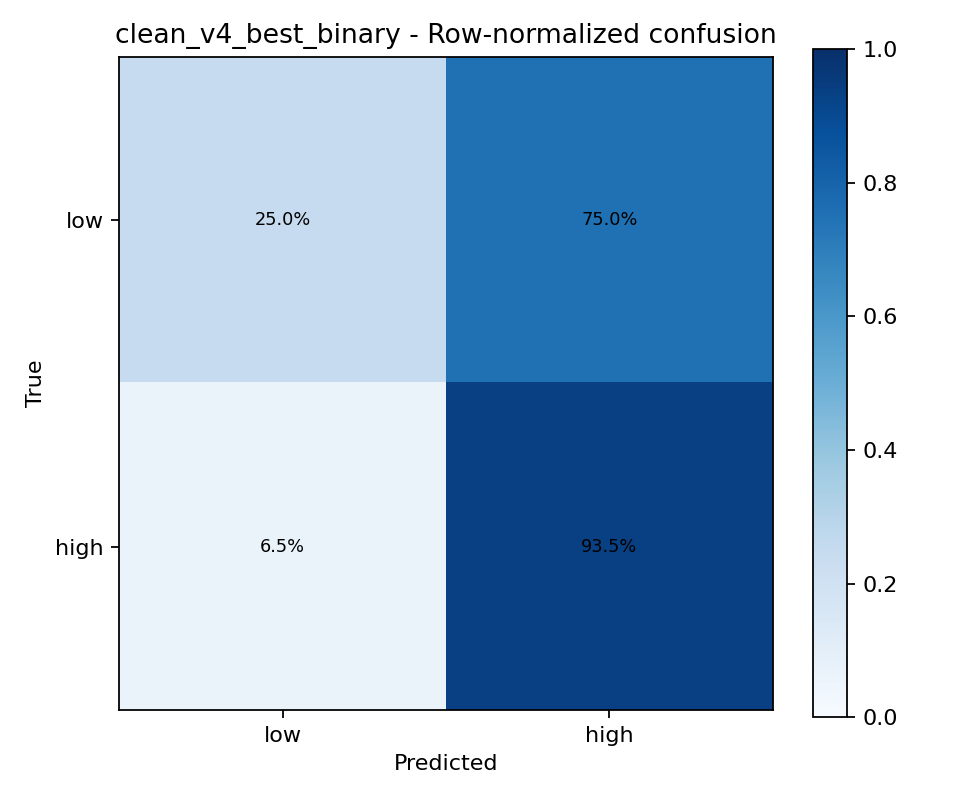

,pred_low,pred_high
true_low,0.249819,0.750181
true_high,0.064507,0.935493


In [8]:
confusion_names = [
    "clean_v2_ce",
    "clean_v2_ordinal_smoothing",
    "clean_v2_emd",
    "clean_v2_expected_mse_aux",
    "clean_v3_binary_f1_optimal",
    "clean_v4_best_binary",
]

for name in confusion_names:
    img = plot_dir / f"{name}_confusion_row_normalized.png"
    csv = report_dir / f"{name}_confusion_row_normalized.csv"
    display(Markdown(f"### {name}"))
    if img.exists():
        display(Image(filename=str(img)))
    else:
        print("missing plot:", img)
    if csv.exists():
        display(pd.read_csv(csv, index_col=0))

## 8. v4 threshold ?? ?

?? v4? ???? F1-optimal ? precision-optimal @ recall>=0.7 ??? ?? ?????.

In [9]:
display(pd.read_csv(report_dir / "clean_v4_threshold_sweeps.csv").head())


,threshold,accuracy,precision,recall,f1,auc_pr,auc_roc,method,score_column
0,0.010,0.623677,0.623535,0.998241,0.767600,0.819018,0.738701,Binary MLP probability,binary_mlp_prob
1,0.015,0.624681,0.624232,0.997801,0.767998,0.819018,0.738701,Binary MLP probability,binary_mlp_prob
2,0.020,0.625502,0.624885,0.996921,0.768231,0.819018,0.738701,Binary MLP probability,binary_mlp_prob
3,0.025,0.626506,0.625587,0.996481,0.768631,0.819018,0.738701,Binary MLP probability,binary_mlp_prob
4,0.030,0.626780,0.625945,0.995309,0.768552,0.819018,0.738701,Binary MLP probability,binary_mlp_prob


In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, average_precision_score, roc_auc_score
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent

OUT = ROOT / "outputs" / "clean_label_v2_v3_v4"
REPORT_DIR = OUT / "reports"
PRED_DIR = OUT / "predictions"

oof_path = PRED_DIR / "BSD10k_oof_clean_v4_scores.csv"
bsd35_path = PRED_DIR / "BSD35k-CS_clean_v4_scores.csv"
summary_path = REPORT_DIR / "clean_v4_score_stacking_summary.csv"

oof = pd.read_csv(oof_path)
bsd35 = pd.read_csv(bsd35_path)
summary = pd.read_csv(summary_path)

def metrics_at_threshold(y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "auc_pr": average_precision_score(y_true, score),
        "auc_roc": roc_auc_score(y_true, score),
    }

f1_candidates = summary[summary["selection"] == "F1-optimal"].copy()
best_row = f1_candidates.sort_values(["f1", "auc_pr"], ascending=[False, False]).iloc[0]

best_method = str(best_row["method"])
best_col = str(best_row["score_column"])
best_threshold = float(best_row["threshold"])

if best_col == "fiveclass_score":
    thresholds = sorted(set([best_threshold, 3.0, 3.25, 3.5, 3.75, 4.0]))
elif best_col == "fiveclass_margin_p45_minus_p3":
    thresholds = sorted(set([best_threshold, -0.2, 0.0, 0.2, 0.4, 0.6]))
else:
    thresholds = sorted(set([best_threshold, 0.5, 0.6, 0.7, 0.8, 0.9]))

y_true = oof["target_high_confidence"].to_numpy(dtype=int)
oof_score = oof[best_col].to_numpy(dtype=float)
bsd35_score = bsd35[best_col].to_numpy(dtype=float)

rows = []
for threshold in thresholds:
    m = metrics_at_threshold(y_true, oof_score, threshold)
    rows.append({
        "method": best_method,
        "score_column": best_col,
        "threshold": threshold,
        "retained_samples": int((bsd35_score >= threshold).sum()),
        "retained_ratio": float((bsd35_score >= threshold).mean()),
        "expected_precision_from_oof": m["precision"],
        "expected_recall_from_oof": m["recall"],
        "expected_f1_from_oof": m["f1"],
    })

scenario = pd.DataFrame(rows)
scenario.to_csv(REPORT_DIR / "clean_v4_bsd35k_filtering_scenarios.csv", index=False)
scenario.to_csv(PRED_DIR / "BSD35k-CS_clean_v4_threshold_scenarios.csv", index=False)

display(Markdown("### clean v4 BSD35k-CS filtering scenario"))
display(scenario)
print("saved:", REPORT_DIR / "clean_v4_bsd35k_filtering_scenarios.csv")

### clean v4 BSD35k-CS filtering scenario

,method,score_column,threshold,retained_samples,retained_ratio,expected_precision_from_oof,expected_recall_from_oof,expected_f1_from_oof
0,OOF logistic stacker,logistic_stacker_prob,0.36,27927,0.887586,0.672888,0.935493,0.782753
1,OOF logistic stacker,logistic_stacker_prob,0.50,19823,0.630022,0.722378,0.831989,0.773319
2,OOF logistic stacker,logistic_stacker_prob,0.60,12646,0.401920,0.774214,0.714851,0.743349
3,OOF logistic stacker,logistic_stacker_prob,0.70,6131,0.194858,0.829726,0.550799,0.662085
4,OOF logistic stacker,logistic_stacker_prob,0.80,1678,0.053331,0.904561,0.314030,0.466210
5,OOF logistic stacker,logistic_stacker_prob,0.90,446,0.014175,0.945191,0.133998,0.234720


saved: c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4\reports\clean_v4_bsd35k_filtering_scenarios.csv


## 9. ?? ?? ??

In [10]:
for path in [
    report_dir / "clean_v2_summary.csv",
    report_dir / "clean_v3_binary_summary.csv",
    report_dir / "clean_v4_score_stacking_summary.csv",
    pred_dir / "BSD10k_oof_clean_v2.csv",
    pred_dir / "BSD10k_oof_clean_v3_binary.csv",
    pred_dir / "BSD10k_oof_clean_v4_scores.csv",
    pred_dir / "BSD35k-CS_clean_v4_scores.csv",
]:
    print(path, "OK" if path.exists() else "missing")

c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4\reports\clean_v2_summary.csv OK
c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4\reports\clean_v3_binary_summary.csv OK
c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4\reports\clean_v4_score_stacking_summary.csv OK
c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4\predictions\BSD10k_oof_clean_v2.csv OK
c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4\predictions\BSD10k_oof_clean_v3_binary.csv OK
c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4\predictions\BSD10k_oof_clean_v4_scores.csv OK
c:\Users\solok\Desktop\Dcase baseline\outputs\clean_label_v2_v3_v4\predictions\BSD35k-CS_clean_v4_scores.csv OK
